10


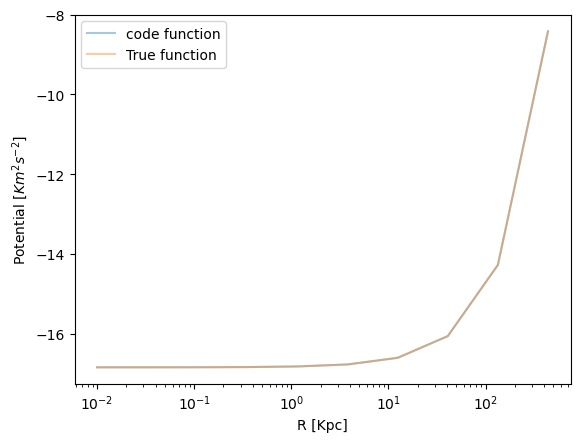

14
18
25
33


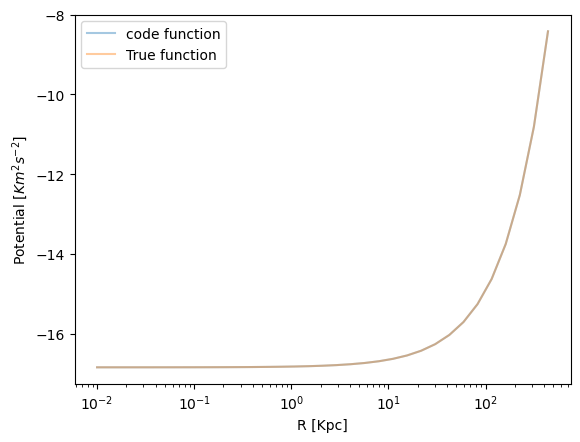

45
61
82
110


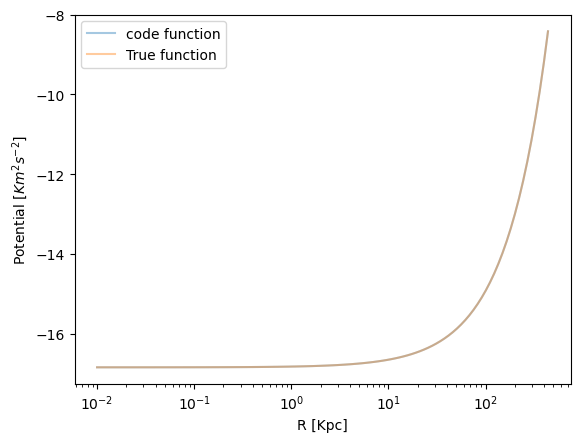

149
201
272
367


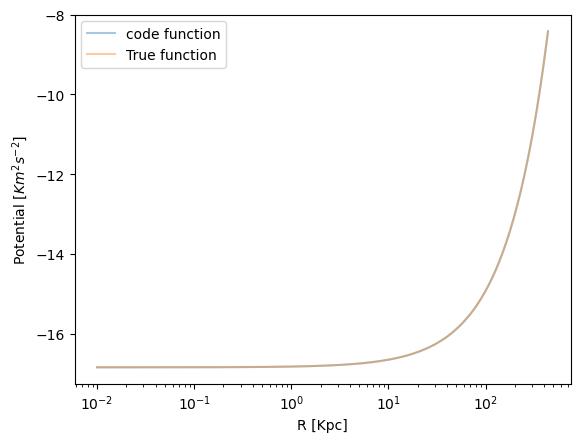

495
669
903
1219


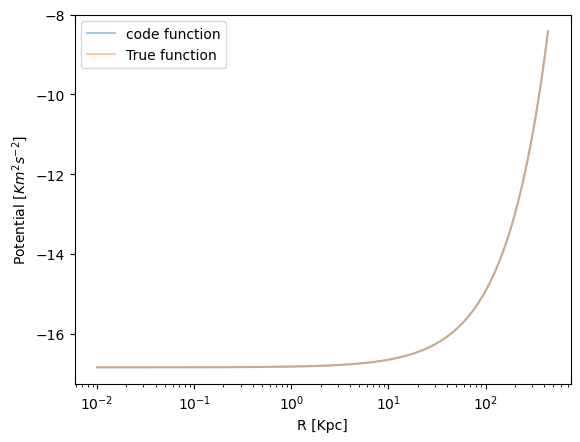

1646
2222
3000
RMS error: [np.float64(0.010031918584416656), np.float64(0.005147778187494202), np.float64(0.0030791012575001634), np.float64(0.0015625860845092175), np.float64(0.000880647535544653), np.float64(0.00046522336394214407), np.float64(0.00024959144685836017), np.float64(0.00013661591324017573), np.float64(7.527882102831304e-05), np.float64(4.0755734378151876e-05), np.float64(2.228493582612095e-05), np.float64(1.2123506233241687e-05), np.float64(6.640815730491435e-06), np.float64(3.6428286404563104e-06), np.float64(1.991217851153944e-06), np.float64(1.0916755970898077e-06), np.float64(5.985337257376039e-07), np.float64(3.280644916555652e-07), np.float64(1.7993902121927902e-07), np.float64(9.867759115982358e-08)]


In [25]:

import jaxsp as jsp
import Stellar_sim_funcs as SSF
import importlib
importlib.reload(SSF)
import numpy as np
import matplotlib.pyplot as plt


rms_all = []


m22 = 1
u = jsp.set_schroedinger_units(m22)



lens = np.logspace(np.log10(10), np.log10(3000), 20)

r_min = 0.01 * u.from_Kpc
r_max = 440 * u.from_Kpc

j = 0
for i in lens:

    print(int(round(i, 0)))

    r_conv = np.logspace(np.log10(r_min), np.log10(r_max), int(round(i, 0)))

    rms, Phi_dt_r, Phi_r_maths = SSF.convergence_rho_to_pot_3d(r_conv)

    rms_all.append(rms)

    if j % 4 == 0:
        plt.plot(r_conv * u.to_Kpc, Phi_dt_r * u.to_kms**2, label = 'code function', alpha = 0.4)
        plt.plot(r_conv * u.to_Kpc, Phi_r_maths * u.to_kms**2, label = 'True function', alpha = 0.4)
        plt.xlabel('R [Kpc]')
        plt.ylabel(r'Potential [$Km^2s^{-2}$]')
        plt.xscale('log')
        plt.legend()
        plt.show()

    j += 1


print(f"RMS error: {rms_all}")


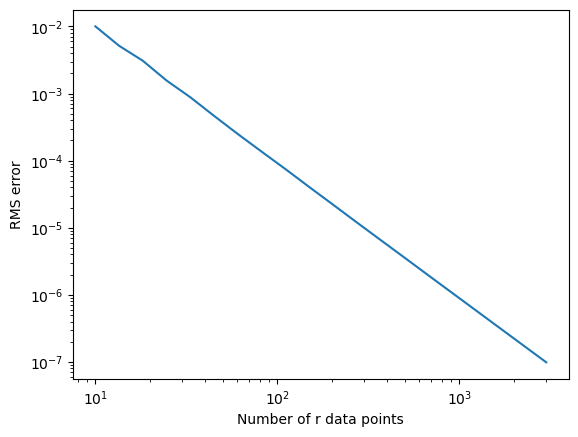

In [26]:
plt.plot(lens, rms_all)
plt.yscale('log')
plt.xlabel('Number of r data points')
plt.ylabel('RMS error')
plt.xscale('log')
plt.show()